In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('train_data.csv')
display(df.head())    

,step,amount,isFraud,isFlaggedFraud,hour,is_night,balance_diff_orig,balance_diff_dest,type_enc
0,1,9839.64,0,0,1,1,9839.64,0.0,3
1,1,1864.28,0,0,1,1,1864.28,0.0,3
2,1,181.00,1,0,1,1,181.00,0.0,4
3,1,181.00,1,0,1,1,181.00,21182.0,1
4,1,11668.14,0,0,1,1,11668.14,0.0,3


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb   
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
x = df.drop(columns=['isFraud','isFlaggedFraud'])
y = df['isFraud'].values

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42 , stratify = y)

print(x_train.shape , x_test.shape)
print(y_train.shape,y_test.shape )

(3175534, 7) (793884, 7)
(3175534,) (793884,)


In [3]:
Pipe_lr = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , LogisticRegression(
        max_iter=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
        
    ))
])

pipe_rf = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
fraud_count     = (y_train == 0).sum()
non_fraud_count = (y_train == 1).sum()
scale_pos       = fraud_count / non_fraud_count  
scale_pos  = fraud_count / non_fraud_count   # auto balance ratio


pipe_xg = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , xgb.XGBClassifier(
        n_estimators = 100,
        max_depth = 6,
        learning_rate = 0.1,
        subsample = 0.8,
        tree_method = 'hist',
        n_jobs = -1,
        scale_pos_weight = scale_pos
    ))
])

train_pipelines = {
    'Logistic Regression' : Pipe_lr,
    'Random Forest Classifier' : pipe_rf,
    "XGBoost Classifier" : pipe_xg
}

for name , pipe in train_pipelines.items():
    print(f"train : {name}")
    pipe.fit(x_train , y_train)
    print(f"model : {name} trained sucessfully")

train : Logistic Regression
model : Logistic Regression trained sucessfully
train : Random Forest Classifier
model : Random Forest Classifier trained sucessfully
train : XGBoost Classifier
model : XGBoost Classifier trained sucessfully


In [4]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score, roc_curve ,auc
results = []
for name , pipe in train_pipelines.items():
    y_pred = pipe.predict(x_test)
    accuracy =  accuracy_score(y_test , y_pred)
    y_pred_proba = pipe.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    report = classification_report(y_test , y_pred , output_dict=True)

    results.append({
        'Model'     : name,
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'],    4),
        'F1-Score'  : round(report['1']['f1-score'],  4), # i need to understand this 
        'AUC-ROC'   : round(roc_auc, 4)
    })

    print(f"model : {name}")
    # print(f"prediction : {y_pred}")
    print(f"accuracy : {accuracy}")
    print(f"ROC_AUC : {roc_auc}")
    print(f"{'='*45}")
    print(f"classification report : \n {classification_report(y_test , y_pred)}")
    print(f"{'='*45}")
    print("confusion matrix:")
    print(confusion_matrix(y_test , y_pred))
    print(f"{'='*45} \n ")


model : Logistic Regression
accuracy : 0.9557832126607918
ROC_AUC : 0.9691127334942269
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    793209
           1       0.02      0.88      0.03       675

    accuracy                           0.96    793884
   macro avg       0.51      0.92      0.50    793884
weighted avg       1.00      0.96      0.98    793884

confusion matrix:
[[758190  35019]
 [    84    591]]
 
model : Random Forest Classifier
accuracy : 0.9779791506063858
ROC_AUC : 0.995514114887193
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    793209
           1       0.04      0.94      0.07       675

    accuracy                           0.98    793884
   macro avg       0.52      0.96      0.53    793884
weighted avg       1.00      0.98      0.99    793884

confusion matrix:
[[775768  17441]
 [    41    634]]
 
model 

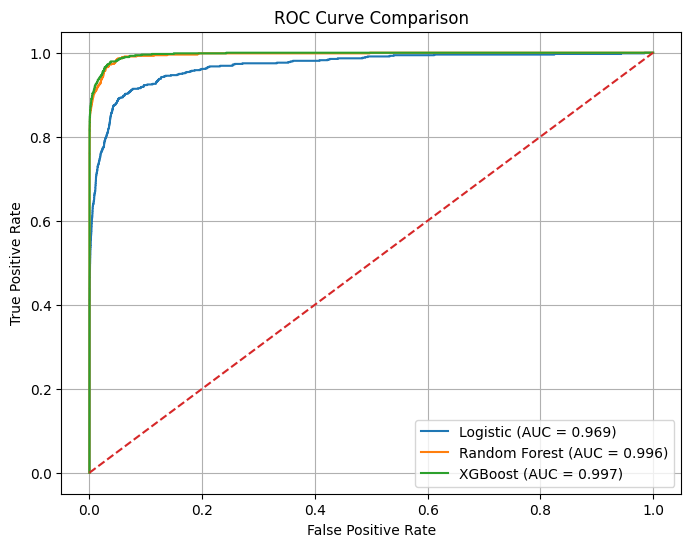

In [5]:
# get probability
log_prob = train_pipelines['Logistic Regression'].predict_proba(x_test)[:,1]

rf_prob = train_pipelines['Random Forest Classifier'].predict_proba(x_test)[:,1]

xgb_prob = train_pipelines['XGBoost Classifier'].predict_proba(x_test)[:,1]

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()



top 10 best feature base on model train

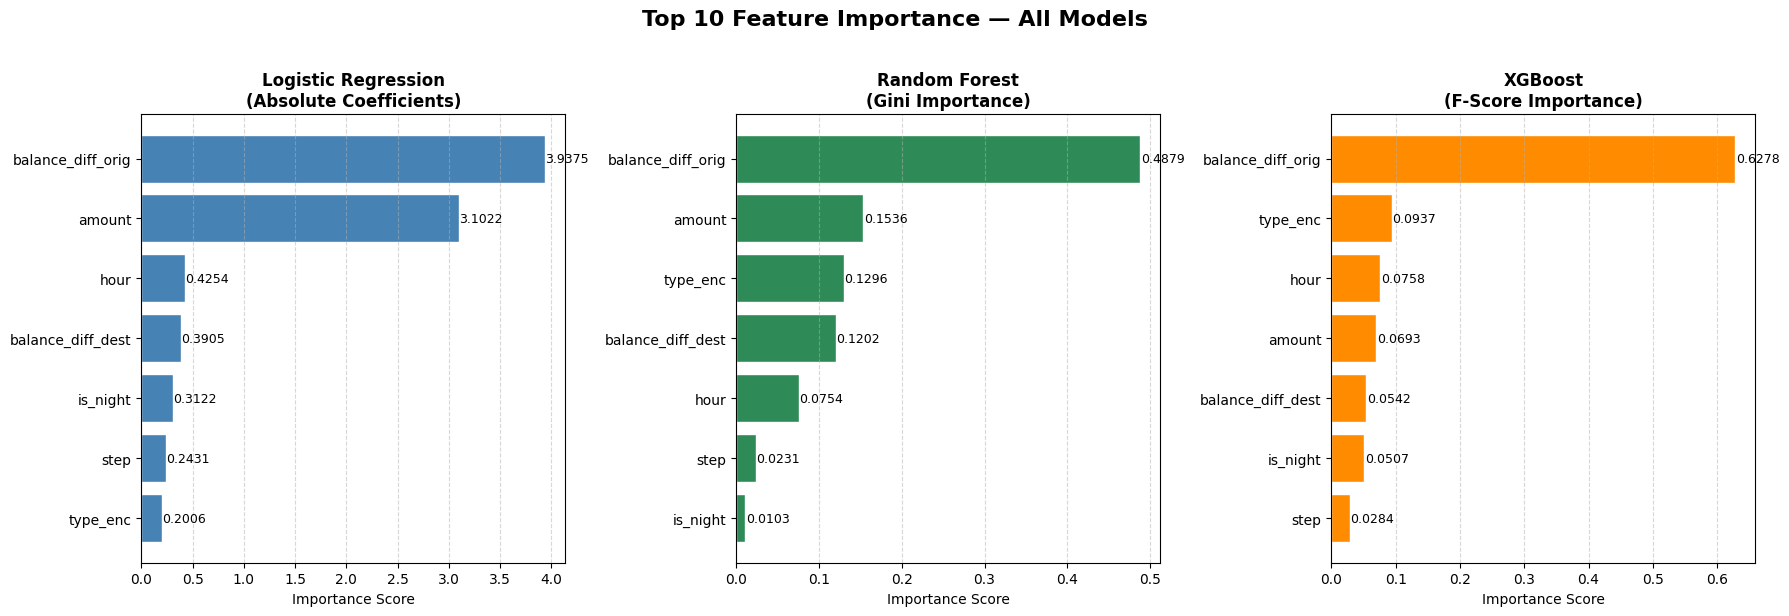

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Feature Importance — All Models', fontsize=16, fontweight='bold', y=1.02)
feature_names = x.columns.tolist()

# ── 1. Logistic Regression — Coefficients as Importance ──────────────────────
ax1 = axes[0]

lr_model      = Pipe_lr.named_steps['model']
lr_importance = np.abs(lr_model.coef_[0])          # absolute coefficients
lr_indices    = np.argsort(lr_importance)[::-1][:10]  # top 10

lr_features = [feature_names[i] for i in lr_indices]
lr_values   = lr_importance[lr_indices]

bars = ax1.barh(lr_features[::-1], lr_values[::-1], color='steelblue', edgecolor='white')
ax1.set_title('Logistic Regression\n(Absolute Coefficients)', fontweight='bold')
ax1.set_xlabel('Importance Score')
for bar, val in zip(bars, lr_values[::-1]):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax1.grid(axis='x', linestyle='--', alpha=0.5)


# ── 2. Random Forest — Built-in Feature Importance ───────────────────────────
ax2 = axes[1]

rf_model      = pipe_rf.named_steps['model']
rf_importance = rf_model.feature_importances_
rf_indices    = np.argsort(rf_importance)[::-1][:10]

rf_features = [feature_names[i] for i in rf_indices]
rf_values   = rf_importance[rf_indices]

bars = ax2.barh(rf_features[::-1], rf_values[::-1], color='seagreen', edgecolor='white')
ax2.set_title('Random Forest\n(Gini Importance)', fontweight='bold')
ax2.set_xlabel('Importance Score')
for bar, val in zip(bars, rf_values[::-1]):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax2.grid(axis='x', linestyle='--', alpha=0.5)


# ── 3. XGBoost — Built-in Feature Importance ─────────────────────────────────
ax3 = axes[2]

xgb_model      = pipe_xg.named_steps['model']
xgb_importance = xgb_model.feature_importances_
xgb_indices    = np.argsort(xgb_importance)[::-1][:10]

xgb_features = [feature_names[i] for i in xgb_indices]
xgb_values   = xgb_importance[xgb_indices]

bars = ax3.barh(xgb_features[::-1], xgb_values[::-1], color='darkorange', edgecolor='white')
ax3.set_title('XGBoost\n(F-Score Importance)', fontweight='bold')
ax3.set_xlabel('Importance Score')
for bar, val in zip(bars, xgb_values[::-1]):
    ax3.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax3.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()